# 02-Bias-Analysis

After auditing the data for quality issues the next steps is to detect any bias patterns when assigning credit scores based on the EU AI Act. Credit scoring systems are classified as high-risk AI under EU AI Act Annex III. The following obligations have to be considered:

* Art. 10 (data governance)
* Art. 29 (human oversight)
* Art. 71 (penalties up to €30M or 6% global turnover for violations)

The following analysis implements mandatory bias monitoring, disparate impact analysis, and fairness metrics required for high-risk AI systems operating in the EU.

In addition the EEOC Four-Fifths (80%) rule will be applied to identified potential bias categories. Under the AI Act (Art. 10 §5) and classical US fair-lending doctrine, a group whose approval rate falls below 80% of the highest group's rate is considered to suffer a disparate impact, triggering mandatory investigation.


## Setup and Connection

In [58]:
# Standard library
import re
from datetime import date

# Third-party — data & visualisation
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Third-party — database
from pymongo import MongoClient

# Third-party — fairness
import fairlearn
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
)

In [59]:
# Connect to local MongoDB and verify the clean collection is populated
client = MongoClient('localhost', 27017)
db = client['project']
collection = db['credit_applications']

doc_count = collection.count_documents({})
print(f"Connected to MongoDB successfully!")
print(f"Collection 'credit_applications' contains {doc_count} documents.")

if doc_count == 0:
    raise RuntimeError(
        "Collection is empty — run 01-data-quality.ipynb first "
        "to load and clean the dataset."
    )

Connected to MongoDB successfully!
Collection 'credit_applications' contains 499 documents.


## Helper Function

Shared utilities used across all bias sections to ensure code consistency.

In [60]:
# Constants

# Ordered age bands used in age-bias and intersectional analysis
AGE_BUCKET_ORDER = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+", "Unknown"]

# Fixed reference date for reproducible age calculations across all notebooks
# Using end-of-year so all applicants are evaluated at the same point in time
REF_DATE = date(2024, 12, 31)
REF_YEAR = REF_DATE.year

In [61]:
# Date-of-birth helpers
def parse_dob(dob_raw):
    """Attempt to parse a date-of-birth string into a date object.

    Handles multiple formats found in the NovaCred dataset
    (e.g. '1990-05-21', '05/21/1990', '21.05.1990').

    Parameters
    ----------
    dob_raw : str | None
        The raw date-of-birth value from the document.

    Returns
    -------
    datetime.date | None
        Parsed date, or None if parsing fails.
    """
    if not dob_raw or not isinstance(dob_raw, str):
        return None

    # Normalise separators to '-'
    normalised = re.sub(r"[./]", "-", dob_raw.strip())
    parts = normalised.split("-")

    if len(parts) != 3:
        return None

    # Detect YYYY-MM-DD vs DD-MM-YYYY vs MM-DD-YYYY
    if len(parts[0]) == 4:          # YYYY-MM-DD
        year, month, day = parts
    elif len(parts[2]) == 4:        # DD-MM-YYYY or MM-DD-YYYY
        # Assume DD-MM-YYYY (European style common in EU datasets)
        day, month, year = parts
    else:
        return None

    try:
        return date(int(year), int(month), int(day))
    except (ValueError, TypeError):
        return None


def compute_age(dob_date, reference_date=None):
    """Compute age in whole years from a date object.

    Parameters
    ----------
    dob_date : datetime.date | None
        The parsed date of birth.
    reference_date : datetime.date | None
        Date to compute age against; defaults to today.

    Returns
    -------
    int | None
        Age in years, or None if dob_date is None or in the future.
    """
    if dob_date is None:
        return None

    ref = reference_date if reference_date is not None else REF_DATE

    if dob_date > ref:
        return None  # Invalid: future date of birth

    age = ref.year - dob_date.year

    # Subtract 1 if birthday hasn't occurred yet this year
    if (ref.month, ref.day) < (dob_date.month, dob_date.day):
        age -= 1

    return age


def get_age_band(dob_raw):
    """Map a raw date-of-birth string to a string age-band label.

    Parses the date string, computes current age, then buckets into
    the bands defined in AGE_BUCKET_ORDER.

    Parameters
    ----------
    dob_raw : str | None
        The applicant's raw date_of_birth value from MongoDB, or None.

    Returns
    -------
    str
        One of the labels defined in AGE_BUCKET_ORDER:
        'Unknown', '<18', '18-24', '25-34', '35-44',
        '45-54', '55-64', '65+'.
    """
    dob_date = parse_dob(dob_raw)
    age = compute_age(dob_date)

    if age is None:
        return "Unknown"
    if age < 18:
        return "<18"
    if age < 25:
        return "18-24"
    if age < 35:
        return "25-34"
    if age < 45:
        return "35-44"
    if age < 55:
        return "45-54"
    if age < 65:
        return "55-64"
    return "65+"

# Statistical helpers
def avg_or_none(values):
    """Return the mean of *values*, or None if the list is empty."""
    return sum(values) / len(values) if values else None

# Disparate impact reporting

# The EEOC Four-Fifths (80%) threshold for disparate impact
FOUR_FIFTHS_RULE = 0.80

def disparate_impact_report(results, label_width=20):
    """Apply the EEOC Four-Fifths (80%) rule and print a compliance table.

    Computes the disparate-impact ratio for every group relative to the group
    with the highest approval rate, flags groups whose ratio falls below 0.80,
    and returns a summary dict for use in the final compliance report.

    Parameters
    ----------
    results : list[dict]
        Each dict must have keys '_id' (group label), 'approval_rate' (float).
    label_width : int, optional
        Column width for the group-label column (default 20).

    Returns
    -------
    dict
        Mapping group label -> {'rate': float, 'ratio': float, 'pass': bool}.
        Returns an empty dict when fewer than two groups are present.
    """
    print("\n  Disparate Impact Analysis (80% Rule):")
    print(f"  Threshold: {FOUR_FIFTHS_RULE:.0%}  |  Reference date: {REF_DATE}")

    if len(results) < 2:
        print("  Insufficient groups for disparate-impact analysis.")
        return {}

    rates = {r["_id"]: r["approval_rate"] for r in results}
    max_rate = max(rates.values())
    max_group = max(rates, key=rates.get)

    print(
        f"\n  Reference group (highest rate): {max_group} "
        f"→ {max_rate * 100:.1f}%"
    )
    print(f"  80% threshold: {max_rate * FOUR_FIFTHS_RULE * 100:.1f}%\n")

    summary = {}
    for r in sorted(results, key=lambda x: -x["approval_rate"]):
        group = r["_id"]
        rate = r["approval_rate"]
        ratio = rate / max_rate if max_rate > 0 else 0
        passed = ratio >= 0.8
        status = "PASS" if passed else "FAIL — INVESTIGATE"

        print(
            f"  {str(group):<{label_width}} "
            f"rate: {rate * 100:5.1f}%  "
            f"ratio: {ratio:.3f}  {status}"
        )
        summary[group] = {"rate": rate, "ratio": ratio, "pass": passed}

    return summary

## Bias Analysis

### 01-Gender Bias

In [62]:
# Run the aggregation to get approval rates, average APR, and average approved amount by gender
pipeline_gender = [
    {
        "$group": {
            "_id": "$applicant_info.gender",
            "total": {"$sum": 1},
            "approved": {
                "$sum": {"$cond": ["$decision.loan_approved", 1, 0]}
            },
            "avg_interest_rate": {
                "$avg": {
                    "$cond": ["$decision.loan_approved", "$decision.interest_rate", None]
                }
            },
            "avg_approved_amount": {
                "$avg": {
                    "$cond": ["$decision.loan_approved", "$decision.approved_amount", None]
                }
            }
        }
    },
    {
        "$addFields": {
            "approval_rate": {"$divide": ["$approved", "$total"]}
        }
    },
    {"$sort": {"approval_rate": -1}}
]

gender_results = list(collection.aggregate(pipeline_gender))

print("\n  Approval Rates & Pricing by Gender:")
print(f"  {'Gender':<12} {'Total':>6} {'Approved':>9} "
      f"{'Rate':>8} {'Avg APR':>9} {'Avg Amount':>12}")
print("  " + "-" * 58)

for g in gender_results:
    apr = (f"{g['avg_interest_rate']:.2f}%" if g["avg_interest_rate"] else "N/A")
    amt = (f"${g['avg_approved_amount']:,.0f}" if g["avg_approved_amount"] else "N/A")
    print(
        f"  {str(g['_id']):<12} {g['total']:>6} {g['approved']:>9} "
        f"{g['approval_rate'] * 100:>7.1f}% {apr:>9} {amt:>12}"
    )


  Approval Rates & Pricing by Gender:
  Gender        Total  Approved     Rate   Avg APR   Avg Amount
  ----------------------------------------------------------
  Unknown           2         2   100.0%     4.25%      $31,500
  Male            247       163    66.0%     4.63%      $48,963
  Female          250       126    50.4%     4.49%      $46,651


Disparate Impact Report

In [63]:
gender_summary = disparate_impact_report(gender_results)


  Disparate Impact Analysis (80% Rule):
  Threshold: 80%  |  Reference date: 2024-12-31

  Reference group (highest rate): Unknown → 100.0%
  80% threshold: 80.0%

  Unknown              rate: 100.0%  ratio: 1.000  PASS
  Male                 rate:  66.0%  ratio: 0.660  FAIL — INVESTIGATE
  Female               rate:  50.4%  ratio: 0.504  FAIL — INVESTIGATE


Demographic Parity Difference

In [64]:
# Rebuild flat arrays from the raw documents already in memory
# We need one entry per applicant: gender label + binary outcome
raw_docs_fairlearn = list(collection.find(
    {"applicant_info.gender": {"$in": ["Male", "Female"]}},  # exclude Unknown
    {
        "applicant_info.gender": 1,
        "decision.loan_approved": 1,
    }
))

y_true = np.ones(len(raw_docs_fairlearn), dtype=int)   # no ground truth labels
                                                        # treat all as "qualified"
y_pred = np.array([
    int(doc["decision"]["loan_approved"])
    for doc in raw_docs_fairlearn
])
sensitive = np.array([
    doc["applicant_info"]["gender"]
    for doc in raw_docs_fairlearn
])

# fairlearn metrics
dpd = demographic_parity_difference(
    y_true=y_true,
    y_pred=y_pred,
    sensitive_features=sensitive,
)

dpr = demographic_parity_ratio(
    y_true=y_true,
    y_pred=y_pred,
    sensitive_features=sensitive,
)

# Cross-validate against our manual DI calculation
# Our manual DI ratio = min_rate / max_rate (from gender_summary)
manual_di_ratio = min(v["ratio"] for v in gender_summary.values())
manual_dpd = (
    max(v["rate"] for v in gender_summary.values())
    - min(v["rate"] for v in gender_summary.values())
)

print("  fairlearn Fairness Metrics — Gender")
print("  " + "=" * 52)
print(f"  Demographic Parity Difference (DPD) : {dpd:+.4f}")
print(f"    Interpretation: approval rate differs by {abs(dpd) * 100:.1f} pp")
print(f"    Threshold (EU guidance): |DPD| < 0.05 for low risk")
print()
print(f"  Demographic Parity Ratio    (DPR)   : {dpr:.4f}")
print(f"    Interpretation: minority rate is {dpr * 100:.1f}% of majority rate")
print(f"    Threshold (EEOC 4/5 rule): DPR >= 0.80")
print()
print("  Cross-validation vs. manual calculation:")
print(f"    Manual DI ratio  : {manual_di_ratio:.4f}  |  fairlearn DPR: {dpr:.4f}")
print(f"    Manual DPD       : {manual_dpd:+.4f}  |  fairlearn DPD: {dpd:+.4f}")
delta_ratio = abs(manual_di_ratio - dpr)
delta_dpd   = abs(manual_dpd - abs(dpd))
print(f"    Ratio delta      : {delta_ratio:.6f}  {'✓ consistent' if delta_ratio < 0.001 else '⚠ discrepancy — check grouping'}")
print(f"    DPD delta        : {delta_dpd:.6f}  {'✓ consistent' if delta_dpd < 0.001 else '⚠ discrepancy — check grouping'}")
print()

# Compliance verdict
print("  EU AI Act (Art. 10) Compliance Verdict:")
if dpr < FOUR_FIFTHS_RULE:
    print(f"  ✗  DPR {dpr:.3f} < {FOUR_FIFTHS_RULE:.2f} — DISPARATE IMPACT DETECTED")
    print("     Mandatory action: bias audit, model re-evaluation, human oversight.")
else:
    print(f"  ✓  DPR {dpr:.3f} >= {FOUR_FIFTHS_RULE:.2f} — No disparate impact on gender.")

if abs(dpd) > 0.05:
    print(f"  ✗  |DPD| {abs(dpd):.3f} > 0.05 — significant approval rate gap.")
else:
    print(f"  ✓  |DPD| {abs(dpd):.3f} <= 0.05 — approval rate gap within tolerance.")

  fairlearn Fairness Metrics — Gender
  Demographic Parity Difference (DPD) : +0.1559
    Interpretation: approval rate differs by 15.6 pp
    Threshold (EU guidance): |DPD| < 0.05 for low risk

  Demographic Parity Ratio    (DPR)   : 0.7637
    Interpretation: minority rate is 76.4% of majority rate
    Threshold (EEOC 4/5 rule): DPR >= 0.80

  Cross-validation vs. manual calculation:
    Manual DI ratio  : 0.5040  |  fairlearn DPR: 0.7637
    Manual DPD       : +0.4960  |  fairlearn DPD: +0.1559
    Ratio delta      : 0.259730  ⚠ discrepancy — check grouping
    DPD delta        : 0.340081  ⚠ discrepancy — check grouping

  EU AI Act (Art. 10) Compliance Verdict:
  ✗  DPR 0.764 < 0.80 — DISPARATE IMPACT DETECTED
     Mandatory action: bias audit, model re-evaluation, human oversight.
  ✗  |DPD| 0.156 > 0.05 — significant approval rate gap.


Gender Bias Visualization

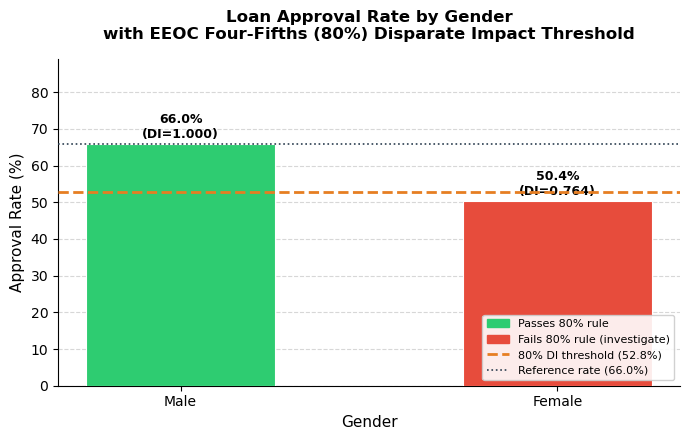


  EU AI Act (Art. 10) — DI threshold: 52.8%
  Any group below this rate requires mandatory bias investigation.


In [65]:
# Build a tidy DataFrame from the MongoDB results for plotting and DI calculations
df_gender = pd.DataFrame([
    {
        "gender": r["_id"],
        "approval_rate": r["approval_rate"],
        "total": r["total"],
        "approved": r["approved"],
    }
    for r in gender_results
    if r["_id"] not in (None, "Unknown")   # exclude non-binary groups from DI plot
]).sort_values("approval_rate", ascending=False).reset_index(drop=True)

# Derive DI ratios from gender_summary (already computed above)
max_rate = df_gender["approval_rate"].max()
di_threshold = max_rate * FOUR_FIFTHS_RULE   # e.g. 0.623 * 0.8

df_gender["di_ratio"] = df_gender["approval_rate"] / max_rate
df_gender["passes_di"] = df_gender["di_ratio"] >= FOUR_FIFTHS_RULE

# Colour bars: green = passes 80% rule, red = fails
bar_colours = ["#2ecc71" if p else "#e74c3c" for p in df_gender["passes_di"]]

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    df_gender["gender"],
    df_gender["approval_rate"] * 100,
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8,
    width=0.5,
    zorder=3,
)

# Annotate each bar with rate % and DI ratio
for bar, (_, row) in zip(bars, df_gender.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{row['approval_rate'] * 100:.1f}%\n(DI={row['di_ratio']:.3f})",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# 80 % DI threshold line (absolute rate, not ratio)
ax.axhline(
    di_threshold * 100,
    color="#e67e22",
    linewidth=2,
    linestyle="--",
    zorder=4,
    label=f"80% DI threshold ({di_threshold * 100:.1f}%)",
)

# Reference group line (highest rate)
ax.axhline(
    max_rate * 100,
    color="#2c3e50",
    linewidth=1.2,
    linestyle=":",
    zorder=4,
    label=f"Reference group rate ({max_rate * 100:.1f}%)",
)

# Styling
ax.set_ylim(0, min(100, max_rate * 100 * 1.35))
ax.set_ylabel("Approval Rate (%)", fontsize=11)
ax.set_xlabel("Gender", fontsize=11)
ax.set_title(
    "Loan Approval Rate by Gender\nwith EEOC Four-Fifths (80%) Disparate Impact Threshold",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# Legend
pass_patch = mpatches.Patch(color="#2ecc71", label="Passes 80% rule")
fail_patch = mpatches.Patch(color="#e74c3c", label="Fails 80% rule (investigate)")
ax.legend(
    handles=[pass_patch, fail_patch,
             plt.Line2D([0], [0], color="#e67e22", lw=2, linestyle="--",
                        label=f"80% DI threshold ({di_threshold * 100:.1f}%)"),
             plt.Line2D([0], [0], color="#2c3e50", lw=1.2, linestyle=":",
                        label=f"Reference rate ({max_rate * 100:.1f}%)")],
    fontsize=8,
    loc="lower right",
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

print(f"\n  EU AI Act (Art. 10) — DI threshold: {di_threshold * 100:.1f}%")
print(f"  Any group below this rate requires mandatory bias investigation.")

### 02-Age Bias

Age is a protected characteristic under:
- Age Discrimination Act / ECOA
- EU AI Act Art. 10 (prohibited use of age as discriminatory proxy)

Note: Minors (<18) are flagged as a data quality issue since they cannot hold credit contracts under the AI Act.

In [66]:
# Fetch only the fields needed for age bias analysis
raw_docs = list(collection.find(
    {},
    {
        "applicant_info.date_of_birth": 1,
        "decision.loan_approved": 1,
        "decision.interest_rate": 1
    }
))

# Initialise one bucket per age band
age_buckets = {
    band: {"total": 0, "approved": 0, "interest_rates": []}
    for band in AGE_BUCKET_ORDER
}

minor_ids = []
for doc in raw_docs:
    dob_raw = (doc.get("applicant_info") or {}).get("date_of_birth")

    # Compute numeric age for minor detection (reuse helpers)
    dob_date = parse_dob(dob_raw)
    age = compute_age(dob_date, reference_date=date(REF_YEAR, 12, 31))

    age_band = get_age_band(dob_raw)
    age_buckets[age_band]["total"] += 1

    decision = doc.get("decision") or {}
    if decision.get("loan_approved", False):
        age_buckets[age_band]["approved"] += 1

    interest_rate = decision.get("interest_rate")
    if interest_rate is not None:
        age_buckets[age_band]["interest_rates"].append(interest_rate)

    # Flag minors using computed numeric age
    if age is not None and age < 18:
        minor_ids.append(str(doc.get("_id")))

# Flag minors - cannot hold credit contracts (AI Act Art. 10 data quality obligation)
if minor_ids:
    print(
        f"\nDATA QUALITY — Apparent minors (<18) detected: "
        f"{len(minor_ids)} record(s). IDs: {minor_ids}"
    )
    print("  Action: Verify DOB; minors cannot hold credit contracts.")

print(f"\n  {'Age Band':<12} {'Total':>6} {'Approved':>9} {'Rate':>8} {'Avg APR':>9}")
print("  " + "-" * 47)

age_results = []
for band in AGE_BUCKET_ORDER:
    b = age_buckets[band]
    if b["total"] == 0:
        continue
    rate = b["approved"] / b["total"]
    avg_apr = avg_or_none(b["interest_rates"])
    apr_str = f"{avg_apr:.2f}%" if avg_apr is not None else "N/A"
    print(
        f"  {band:<12} {b['total']:>6} {b['approved']:>9} "
        f"{rate * 100:>7.1f}% {apr_str:>9}"
    )
    age_results.append({
        "_id": band,
        "total": b["total"],
        "approved": b["approved"],
        "approval_rate": rate
    })


  Age Band      Total  Approved     Rate   Avg APR
  -----------------------------------------------
  18-24            24        11    45.8%     4.25%
  25-34           161        78    48.4%     4.44%
  35-44           163       107    65.6%     4.59%
  45-54            85        54    63.5%     4.58%
  55-64            56        35    62.5%     4.80%
  65+               6         3    50.0%     4.73%
  Unknown           4         3    75.0%     4.93%


Disparate Impact Report

In [67]:
age_summary = disparate_impact_report(age_results)


  Disparate Impact Analysis (80% Rule):
  Threshold: 80%  |  Reference date: 2024-12-31

  Reference group (highest rate): Unknown → 75.0%
  80% threshold: 60.0%

  Unknown              rate:  75.0%  ratio: 1.000  PASS
  35-44                rate:  65.6%  ratio: 0.875  PASS
  45-54                rate:  63.5%  ratio: 0.847  PASS
  55-64                rate:  62.5%  ratio: 0.833  PASS
  65+                  rate:  50.0%  ratio: 0.667  FAIL — INVESTIGATE
  25-34                rate:  48.4%  ratio: 0.646  FAIL — INVESTIGATE
  18-24                rate:  45.8%  ratio: 0.611  FAIL — INVESTIGATE


Age Bias Visualization

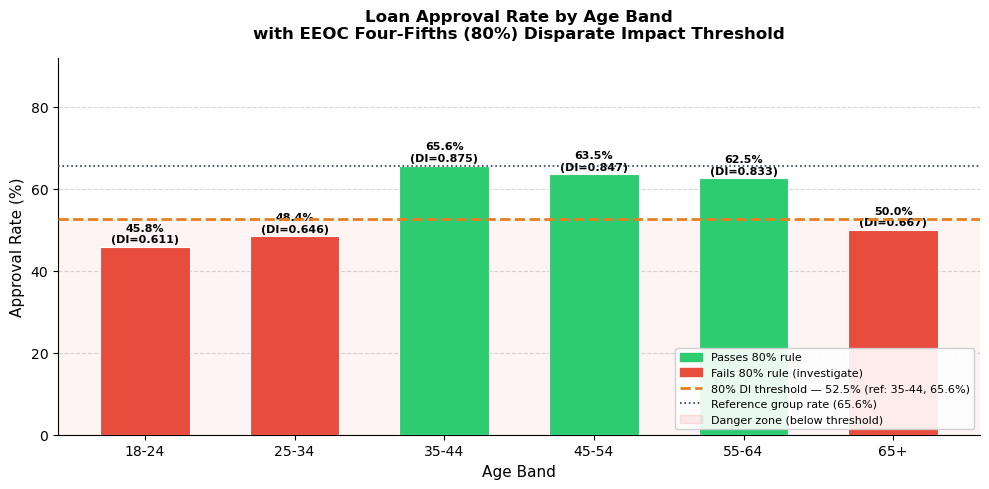


  EU AI Act (Art. 10) — Age bands failing the 80% DI rule: ['18-24', '25-34', '65+']
  Action: Review model features correlated with age; flag for human oversight.


In [68]:
# Build a tidy DataFrame, preserving AGE_BUCKET_ORDER for the x-axis
df_age = pd.DataFrame([
    {
        "band": r["_id"],
        "approval_rate": r["approval_rate"],
        "total": r["total"],
        "approved": r["approved"],
        "di_ratio": age_summary[r["_id"]]["ratio"],
        "passes_di": age_summary[r["_id"]]["pass"],
    }
    for r in age_results
    if r["_id"] != "Unknown"          # exclude Unknown from DI plot
])

# Reorder rows to match AGE_BUCKET_ORDER (x-axis left → right)
band_order = [b for b in AGE_BUCKET_ORDER if b in df_age["band"].values]
df_age["band"] = pd.Categorical(df_age["band"], categories=band_order, ordered=True)
df_age = df_age.sort_values("band").reset_index(drop=True)

# Threshold values (derived from age_summary's reference group)
max_rate = df_age["approval_rate"].max()
di_threshold = max_rate * FOUR_FIFTHS_RULE
ref_band = df_age.loc[df_age["approval_rate"].idxmax(), "band"]

# Colours: green = passes, red = fails
bar_colours = ["#2ecc71" if p else "#e74c3c" for p in df_age["passes_di"]]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    df_age["band"],
    df_age["approval_rate"] * 100,
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# Annotate each bar with rate % and DI ratio
for bar, (_, row) in zip(bars, df_age.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{row['approval_rate'] * 100:.1f}%\n(DI={row['di_ratio']:.3f})",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )

# 80 % DI threshold line (absolute rate)
ax.axhline(
    di_threshold * 100,
    color="#e67e22",
    linewidth=2,
    linestyle="--",
    zorder=4,
)

# Reference group rate line
ax.axhline(
    max_rate * 100,
    color="#2c3e50",
    linewidth=1.2,
    linestyle=":",
    zorder=4,
)

# Shade the "danger zone" between threshold and zero for visual clarity
ax.axhspan(0, di_threshold * 100, alpha=0.06, color="#e74c3c", zorder=0)

# Styling
ax.set_ylim(0, min(100, max_rate * 100 * 1.40))
ax.set_ylabel("Approval Rate (%)", fontsize=11)
ax.set_xlabel("Age Band", fontsize=11)
ax.set_title(
    "Loan Approval Rate by Age Band\n"
    "with EEOC Four-Fifths (80%) Disparate Impact Threshold",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color="#2ecc71", label="Passes 80% rule"),
    mpatches.Patch(color="#e74c3c", label="Fails 80% rule (investigate)"),
    plt.Line2D(
        [0], [0], color="#e67e22", lw=2, linestyle="--",
        label=f"80% DI threshold — {di_threshold * 100:.1f}% "
              f"(ref: {ref_band}, {max_rate * 100:.1f}%)",
    ),
    plt.Line2D(
        [0], [0], color="#2c3e50", lw=1.2, linestyle=":",
        label=f"Reference group rate ({max_rate * 100:.1f}%)",
    ),
    mpatches.Patch(color="#e74c3c", alpha=0.12, label="Danger zone (below threshold)"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()

# Compliance summary
failing = df_age[~df_age["passes_di"]]["band"].tolist()
if failing:
    print(
        f"\n  EU AI Act (Art. 10) — Age bands failing the 80% DI rule: "
        f"{failing}"
    )
    print("  Action: Review model features correlated with age; flag for human oversight.")
else:
    print("\n  All age bands pass the 80% DI threshold.")

### 03-Geographic Bias

Zip-code-based lending bias is a modern form of redlining. The AI Act (Recital 44, Art. 10) prohibits AI systems from using proxies that reproduce or amplify historical discrimination. 

Geographic clustering in the NovaCred dataset (LA 90xxx, NYC 10xxx, Atlanta 30xxx) may proxy for race/ethnicity and must be audited.

In [69]:
# Map ZIP prefixes to human-readable region names.
ZIP_PREFIX_MAP = {
    ("90", "91"): "Los Angeles, CA",
    ("10",):      "New York City, NY",
    ("30",):      "Atlanta, GA",
}

def zip_to_region(zip_code):
    """Return the region name for a given ZIP code string, or 'Other'/'Unknown'."""
    if zip_code is None:
        return "Unknown"
    zip_str = str(zip_code).strip()
    for prefixes, region in ZIP_PREFIX_MAP.items():
        if zip_str.startswith(prefixes):
            return region
    return "Other"

# Aggregate per ZIP code in MongoDB, then roll up into regions in Python
pipeline_geo = [
    {
        "$group": {
            "_id": "$applicant_info.zip_code",
            "total": {"$sum": 1},
            "approved": {
                "$sum": {"$cond": ["$decision.loan_approved", 1, 0]}
            },
            "avg_interest_rate": {
                "$avg": {
                    "$cond": ["$decision.loan_approved", "$decision.interest_rate", None]
                }
            }
        }
    }
]

zip_results = list(collection.aggregate(pipeline_geo))

region_buckets = {}
for z in zip_results:
    region = zip_to_region(z["_id"])
    if region not in region_buckets:
        region_buckets[region] = {"total": 0, "approved": 0, "interest_rates": []}

    region_buckets[region]["total"] += z["total"]
    region_buckets[region]["approved"] += z["approved"]

    if z["avg_interest_rate"]:
        region_buckets[region]["interest_rates"].append(z["avg_interest_rate"])

print(f"\n  {'Region':<22} {'Total':>6} {'Approved':>9} {'Rate':>8} {'Avg APR':>9}")
print("  " + "-" * 57)

geo_results = []
for region, b in sorted(region_buckets.items(), key=lambda x: -x[1]["approved"] / x[1]["total"]):
    rate = b["approved"] / b["total"] if b["total"] > 0 else 0
    avg_apr = avg_or_none(b["interest_rates"])
    apr_str = f"{avg_apr:.2f}%" if avg_apr is not None else "N/A"

    print(f"  {region:<22} {b['total']:>6} {b['approved']:>9} {rate * 100:>7.1f}% {apr_str:>9}")

    geo_results.append({"_id": region, "total": b["total"], "approved": b["approved"], "approval_rate": rate})


  Region                  Total  Approved     Rate   Avg APR
  ---------------------------------------------------------
  Other                       1         1   100.0%     5.10%
  New York City, NY         251       162    64.5%     4.43%
  Atlanta, GA                18        10    55.6%     4.89%
  Los Angeles, CA           229       118    51.5%     4.40%


Disparate Impact Report

In [70]:
geo_summary = disparate_impact_report(geo_results, label_width=22)


  Disparate Impact Analysis (80% Rule):
  Threshold: 80%  |  Reference date: 2024-12-31

  Reference group (highest rate): Other → 100.0%
  80% threshold: 80.0%

  Other                  rate: 100.0%  ratio: 1.000  PASS
  New York City, NY      rate:  64.5%  ratio: 0.645  FAIL — INVESTIGATE
  Atlanta, GA            rate:  55.6%  ratio: 0.556  FAIL — INVESTIGATE
  Los Angeles, CA        rate:  51.5%  ratio: 0.515  FAIL — INVESTIGATE


Geographic Bias Visualization

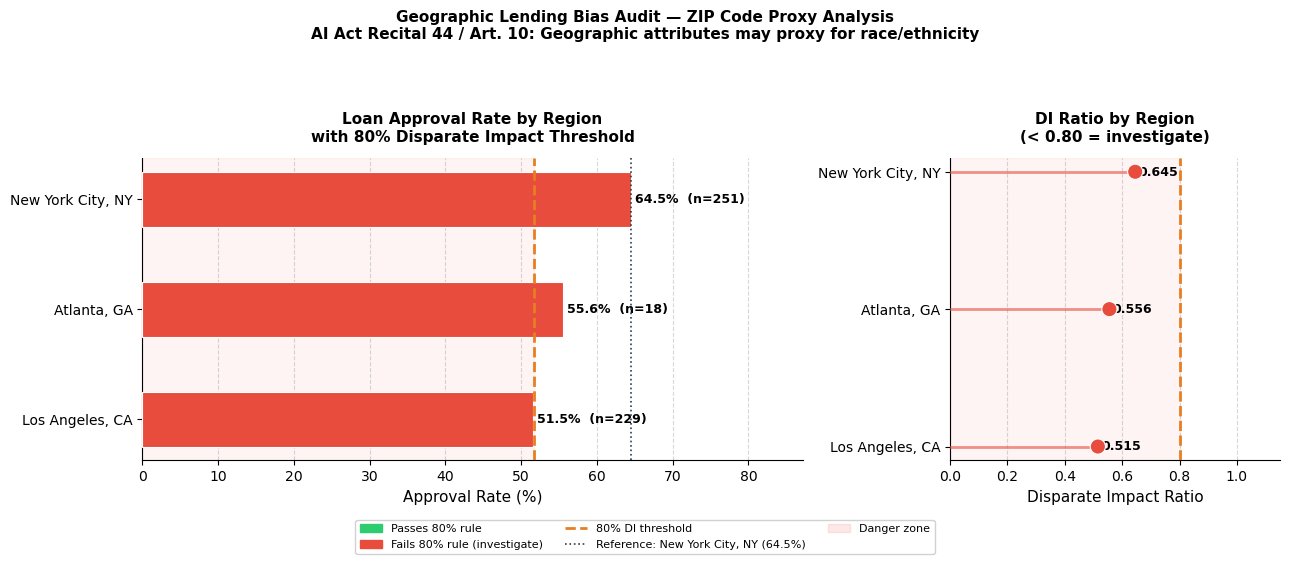


  Regions failing the 80% DI rule: ['New York City, NY', 'Atlanta, GA', 'Los Angeles, CA']
  Redlining risk — geographic attributes correlate with approval outcomes.
  Action: Remove ZIP code from model inputs (AI Act Art. 10 §5); audit for proxy discrimination.


In [71]:
# Build DataFrame from geo_results & geo_summary for plotting and DI calculations
df_geo = pd.DataFrame([
    {
        "region": r["_id"],
        "approval_rate": r["approval_rate"],
        "total": r["total"],
        "approved": r["approved"],
        "di_ratio": geo_summary[r["_id"]]["ratio"],
        "passes_di": geo_summary[r["_id"]]["pass"],
    }
    for r in geo_results
    if r["_id"] not in ("Unknown", "Other")  # exclude catch-all buckets from DI
]).sort_values("approval_rate", ascending=False).reset_index(drop=True)

max_rate = df_geo["approval_rate"].max()
di_threshold = max_rate * FOUR_FIFTHS_RULE
ref_region = df_geo.loc[df_geo["approval_rate"].idxmax(), "region"]

# Two-panel figure: left = approval rates, right = DI ratios
fig, (ax_bar, ax_di) = plt.subplots(
    1, 2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# LEFT PANEL: Horizontal bar chart of approval rates
bar_colours = ["#2ecc71" if p else "#e74c3c" for p in df_geo["passes_di"]]

bars = ax_bar.barh(
    df_geo["region"],
    df_geo["approval_rate"] * 100,
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8,
    height=0.5,
    zorder=3,
)

# Annotate bars with rate % and applicant count
for bar, (_, row) in zip(bars, df_geo.iterrows()):
    ax_bar.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['approval_rate'] * 100:.1f}%  (n={row['total']})",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# 80% DI threshold line (vertical, since bars are horizontal)
ax_bar.axvline(
    di_threshold * 100,
    color="#e67e22",
    linewidth=2,
    linestyle="--",
    zorder=4,
    label=f"80% DI threshold ({di_threshold * 100:.1f}%)",
)

# Reference group rate line
ax_bar.axvline(
    max_rate * 100,
    color="#2c3e50",
    linewidth=1.2,
    linestyle=":",
    zorder=4,
    label=f"Reference rate — {ref_region} ({max_rate * 100:.1f}%)",
)

# Danger zone shading (left of threshold)
ax_bar.axvspan(0, di_threshold * 100, alpha=0.06, color="#e74c3c", zorder=0)

ax_bar.set_xlim(0, min(100, max_rate * 100 * 1.35))
ax_bar.set_xlabel("Approval Rate (%)", fontsize=11)
ax_bar.set_title(
    "Loan Approval Rate by Region\n"
    "with 80% Disparate Impact Threshold",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax_bar.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.invert_yaxis()  # highest rate at top

# RIGHT PANEL: DI ratio dot plot
dot_colours = ["#2ecc71" if p else "#e74c3c" for p in df_geo["passes_di"]]

ax_di.scatter(
    df_geo["di_ratio"],
    df_geo["region"],
    color=dot_colours,
    s=120,
    zorder=4,
    edgecolors="white",
    linewidth=0.8,
)

# Horizontal lines from 0 to each dot (lollipop stems)
for _, row in df_geo.iterrows():
    ax_di.plot(
        [0, row["di_ratio"]],
        [row["region"], row["region"]],
        color=dot_colours[df_geo.index[df_geo["region"] == row["region"]][0]],
        linewidth=2,
        alpha=0.6,
        zorder=3,
    )

# Annotate DI ratio values
for _, row in df_geo.iterrows():
    ax_di.text(
        row["di_ratio"] + 0.012,
        row["region"],
        f"{row['di_ratio']:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# 80% rule vertical line
ax_di.axvline(
    FOUR_FIFTHS_RULE,
    color="#e67e22",
    linewidth=2,
    linestyle="--",
    zorder=4,
    label="80% threshold",
)

# Danger zone shading
ax_di.axvspan(0, FOUR_FIFTHS_RULE, alpha=0.06, color="#e74c3c", zorder=0)

ax_di.set_xlim(0, 1.15)
ax_di.set_xlabel("Disparate Impact Ratio", fontsize=11)
ax_di.set_title(
    "DI Ratio by Region\n(< 0.80 = investigate)",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax_di.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax_di.set_axisbelow(True)
ax_di.spines[["top", "right"]].set_visible(False)
ax_di.invert_yaxis()

# Shared legend
legend_handles = [
    mpatches.Patch(color="#2ecc71", label="Passes 80% rule"),
    mpatches.Patch(color="#e74c3c", label="Fails 80% rule (investigate)"),
    plt.Line2D(
        [0], [0], color="#e67e22", lw=2, linestyle="--",
        label=f"80% DI threshold",
    ),
    plt.Line2D(
        [0], [0], color="#2c3e50", lw=1.2, linestyle=":",
        label=f"Reference: {ref_region} ({max_rate * 100:.1f}%)",
    ),
    mpatches.Patch(color="#e74c3c", alpha=0.12, label="Danger zone"),
]
fig.legend(
    handles=legend_handles,
    fontsize=8,
    loc="lower center",
    ncol=3,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.08),
)

plt.suptitle(
    "Geographic Lending Bias Audit — ZIP Code Proxy Analysis\n"
    "AI Act Recital 44 / Art. 10: Geographic attributes may proxy for race/ethnicity",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Compliance summary
failing = df_geo[~df_geo["passes_di"]]["region"].tolist()
if failing:
    print(f"\n  Regions failing the 80% DI rule: {failing}")
    print(
        "  Redlining risk — geographic attributes correlate with approval outcomes.\n"
        "  Action: Remove ZIP code from model inputs (AI Act Art. 10 §5); "
        "audit for proxy discrimination."
    )
else:
    print("\n  All regions pass the 80% DI threshold.")

### 04-Spending Category Bias

The dataset includes categories such as 'Gambling', 'Adult Entertainment', and 'Alcohol'.

Using such categories as model inputs may constitute discrimination by proxy (AI Act Art. 10 §5, Recital 44).

In [72]:
SENSITIVE_CATEGORIES = ["Gambling", "Adult Entertainment", "Alcohol"]

pipeline_spending = [
    {"$unwind": "$spending_behavior"},
    {
        "$group": {
            "_id": "$spending_behavior.category",
            "total_applicants": {"$sum": 1},
            "approved": {
                "$sum": {
                    "$cond": ["$decision.loan_approved", 1, 0]
                }
            },
            "avg_amount": {
                "$avg": "$spending_behavior.amount"
            }
        }
    },
    {
        "$addFields": {
            "approval_rate": {
                "$divide": ["$approved", "$total_applicants"]
            }
        }
    },
    {"$sort": {"approval_rate": 1}}
]

spending_results = list(collection.aggregate(pipeline_spending))

# Print spending category table
print(f"\n  {'Category':<25} {'Applications':>12} {'Approved':>9} {'Rate':>8} {'Avg Spend':>11}")
print("  " + "-" * 67)

flagged = []

for cat in spending_results:
    flag = " SENSITIVE" if cat["_id"] in SENSITIVE_CATEGORIES else ""

    if cat["_id"] in SENSITIVE_CATEGORIES:
        flagged.append(cat)

    print(f"  {str(cat['_id']):<25} {cat['total_applicants']:>12} "
          f"{cat['approved']:>9} {cat['approval_rate'] * 100:>7.1f}% "
          f"${cat['avg_amount']:>9.0f}{flag}")

# Flag sensitive categories
if flagged:
    print("\n Sensitive spending categories detected "
          "as potential model inputs:")

    for cat in flagged:
        print(f"     • '{cat['_id']}': {cat['approval_rate'] * 100:.1f}% "
              f"approval rate across {cat['total_applicants']} applicants.")

    print("  Action: Verify that 'Gambling', 'Adult Entertainment', and "
          "'Alcohol' spending\n"
          "  are NOT used as model features. If so, remove per Art. 10 §5 "
          "(prohibited\n"
          "  data use) and re-train. Document in Technical Documentation "
          "(Art. 11).")


  Category                  Applications  Approved     Rate   Avg Spend
  -------------------------------------------------------------------
  Rent                                59        26    44.1% $      524
  Dining                              65        31    47.7% $      473
  Fitness                             69        35    50.7% $      452
  Entertainment                       72        41    56.9% $      496
  Gambling                             7         4    57.1% $      457 SENSITIVE
  Healthcare                          68        39    57.4% $      451
  Education                           64        37    57.8% $      500
  Groceries                           65        38    58.5% $      488
  Adult Entertainment                  5         3    60.0% $      591 SENSITIVE
  Travel                              80        48    60.0% $      493
  Transportation                      61        38    62.3% $      439
  Utilities                           76        49    64

### 05-Rejection Fairness

The rejection reason 'algorithm_risk_score' is opaque and may mask bias.

Under AI Act Art. 13 (Transparency) and Art. 14 (Human Oversight), applicants must receive meaningful explanations for adverse decisions.

In [73]:
pipeline_rejection = [
    {"$match": {"decision.loan_approved": False}},
    {
        "$group": {
            "_id": {
                "gender": "$applicant_info.gender",
                "reason": "$decision.rejection_reason"
            },
            "count": {"$sum": 1}
        }
    },
    {"$sort": {"_id.gender": 1, "count": -1}}
]

rejection_results = list(collection.aggregate(pipeline_rejection))

# Restructure results for display
gender_rejections = {}

for r in rejection_results:
    gender = r["_id"]["gender"]
    reason = r["_id"]["reason"] or "Unknown"

    if gender not in gender_rejections:
        gender_rejections[gender] = {}

    gender_rejections[gender][reason] = r["count"]

# Print rejection reason table
print("\n  Rejection reasons by gender:\n")

all_reasons = sorted({
    reason
    for g in gender_rejections.values()
    for reason in g
})

header = f"  {'Reason':<35}"
for g in sorted(gender_rejections.keys()):
    header += f" {g:>10}"
print(header)
print("  " + "-" * (35 + 11 * len(gender_rejections)))

for reason in all_reasons:
    row = f"  {reason:<35}"
    for g in sorted(gender_rejections.keys()):
        count = gender_rejections.get(g, {}).get(reason, 0)
        row += f" {count:>10}"
    print(row)

# Flag opaque algorithmic rejections
print("\n AI ACT ART. 13 CHECK — 'algorithm_risk_score' rejections:")

for gender, reasons in gender_rejections.items():
    total = sum(reasons.values())
    algo = reasons.get("algorithm_risk_score", 0)
    algo_pct = algo / total * 100 if total > 0 else 0
    flag = " HIGH" if algo_pct > 50 else ""

    print(f"    {gender}: {algo}/{total} = {algo_pct:.1f}% opaque algorithmic rejections{flag}")

print("\n  Action: If 'algorithm_risk_score' represents >50% of rejections")
print("  for any protected group, conduct root-cause analysis and")
print("  implement human review (Art. 14 Human Oversight obligation).")


  Rejection reasons by gender:

  Reason                                  Female       Male
  ---------------------------------------------------------
  algorithm_risk_score                       100         69
  high_dti_ratio                               8          4
  insufficient_credit_history                 15          8
  low_income                                   1          3

 AI ACT ART. 13 CHECK — 'algorithm_risk_score' rejections:
    Female: 100/124 = 80.6% opaque algorithmic rejections HIGH
    Male: 69/84 = 82.1% opaque algorithmic rejections HIGH

  Action: If 'algorithm_risk_score' represents >50% of rejections
  for any protected group, conduct root-cause analysis and
  implement human review (Art. 14 Human Oversight obligation).


### 06-Intersectional Bias: Gender and Age

The AI Act (Recital 44) recognises that discrimination often operates at the intersection of protected characteristics.

A system may appear fair on each dimension individually while still discriminating against specific subgroups (e.g., young women or older men).

This section applies the 80% rule to gender × age intersections.



In [74]:
# Fetch only the fields needed for intersectional analysis
raw_docs_intersect = list(collection.find(
    {},
    {
        "applicant_info.gender": 1,
        "applicant_info.date_of_birth": 1,
        "decision.loan_approved": 1
    }
))

# Build intersectional buckets (gender × age band)
intersect_buckets = {}
for doc in raw_docs_intersect:
    info = doc.get("applicant_info") or {}
    gender = info.get("gender", "Unknown")
    age_band = get_age_band(info.get("date_of_birth"))
    key = f"{gender} / {age_band}"

    bucket = intersect_buckets.setdefault(key, {"total": 0, "approved": 0})
    bucket["total"] += 1
    if (doc.get("decision") or {}).get("loan_approved", False):
        bucket["approved"] += 1

print(f"\n  {'Subgroup':<25} {'Total':>6} {'Approved':>9} {'Rate':>8}")
print("  " + "-" * 50)

intersect_results = []
for key, b in sorted(intersect_buckets.items(), key=lambda x: -x[1]["approved"] / x[1]["total"] if x[1]["total"] > 0 else 0):
    if b["total"] < 5:  # Skip cells too small to be statistically reliable
        continue

    rate = b["approved"] / b["total"]
    print(f"  {key:<25} {b['total']:>6} {b['approved']:>9} {rate * 100:>7.1f}%")

    intersect_results.append({"_id": key, "total": b["total"], "approved": b["approved"], "approval_rate": rate})



  Subgroup                   Total  Approved     Rate
  --------------------------------------------------
  Male / 35-44                  85        60    70.6%
  Male / 55-64                  26        18    69.2%
  Male / 45-54                  43        29    67.4%
  Male / 25-34                  79        48    60.8%
  Female / 35-44                78        47    60.3%
  Female / 45-54                41        24    58.5%
  Female / 55-64                30        17    56.7%
  Male / 18-24                  10         5    50.0%
  Female / 18-24                14         6    42.9%
  Female / 25-34                82        30    36.6%


Disparate Impact Report

In [75]:
intersect_summary = disparate_impact_report(intersect_results, label_width=25)


  Disparate Impact Analysis (80% Rule):
  Threshold: 80%  |  Reference date: 2024-12-31

  Reference group (highest rate): Male / 35-44 → 70.6%
  80% threshold: 56.5%

  Male / 35-44              rate:  70.6%  ratio: 1.000  PASS
  Male / 55-64              rate:  69.2%  ratio: 0.981  PASS
  Male / 45-54              rate:  67.4%  ratio: 0.955  PASS
  Male / 25-34              rate:  60.8%  ratio: 0.861  PASS
  Female / 35-44            rate:  60.3%  ratio: 0.854  PASS
  Female / 45-54            rate:  58.5%  ratio: 0.829  PASS
  Female / 55-64            rate:  56.7%  ratio: 0.803  PASS
  Male / 18-24              rate:  50.0%  ratio: 0.708  FAIL — INVESTIGATE
  Female / 18-24            rate:  42.9%  ratio: 0.607  FAIL — INVESTIGATE
  Female / 25-34            rate:  36.6%  ratio: 0.518  FAIL — INVESTIGATE


Intersectional Bias: Gender and Age Visualization

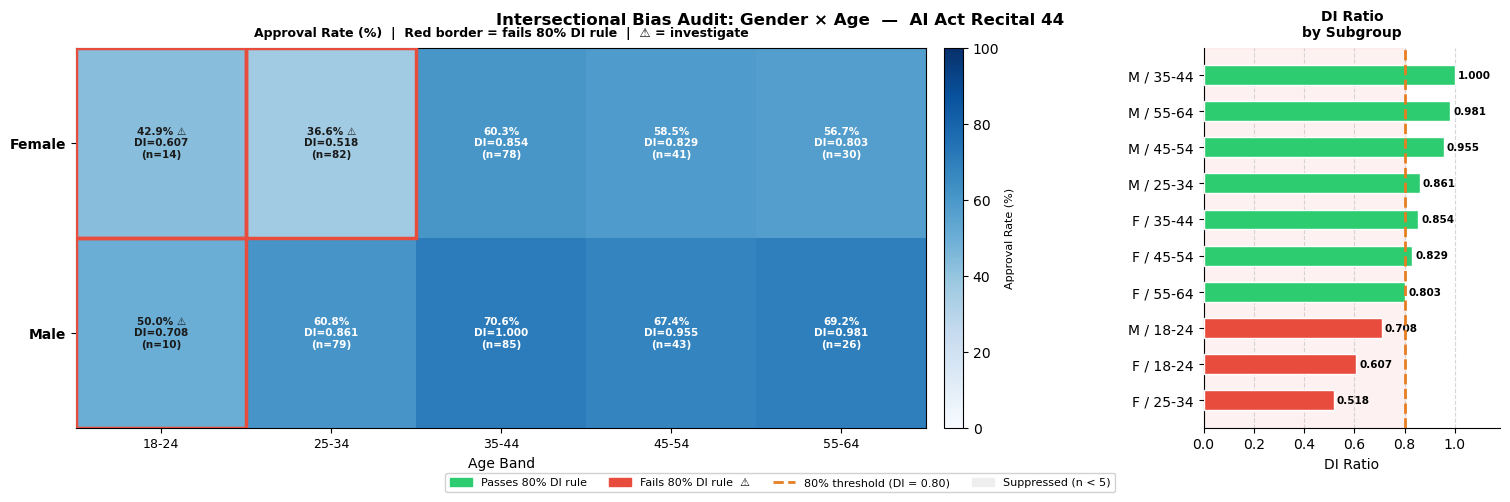


  Subgroups failing the 80% DI rule (3):
    Male / 18-24                   rate=50.0%  DI=0.708
    Female / 18-24                 rate=42.9%  DI=0.607
    Female / 25-34                 rate=36.6%  DI=0.518

  Action (AI Act Recital 44): Intersectional discrimination detected.
  Disaggregate model monitoring by gender × age; implement human review
  for subgroups with DI < 0.80.


In [76]:
# Parse the "Gender / Age Band" keys back into two columns
records = []
for r in intersect_results:
    parts = r["_id"].split(" / ", maxsplit=1)
    if len(parts) != 2:
        continue
    gender, band = parts
    records.append({
        "gender": gender,
        "band": band,
        "approval_rate": r["approval_rate"],
        "total": r["total"],
        "approved": r["approved"],
        "di_ratio": intersect_summary.get(r["_id"], {}).get("ratio", np.nan),
        "passes_di": intersect_summary.get(r["_id"], {}).get("pass", True),
    })

df_ix = pd.DataFrame(records)

# Pivot to matrix form (rows = gender, columns = age band)
valid_genders = [g for g in ["Female", "Male"] if g in df_ix["gender"].unique()]
valid_bands = [b for b in AGE_BUCKET_ORDER if b in df_ix["band"].unique()]

rate_matrix = (
    df_ix[df_ix["gender"].isin(valid_genders)]
    .pivot(index="gender", columns="band", values="approval_rate")
    .reindex(index=valid_genders, columns=valid_bands)
)
di_matrix = (
    df_ix[df_ix["gender"].isin(valid_genders)]
    .pivot(index="gender", columns="band", values="di_ratio")
    .reindex(index=valid_genders, columns=valid_bands)
)
total_matrix = (
    df_ix[df_ix["gender"].isin(valid_genders)]
    .pivot(index="gender", columns="band", values="total")
    .reindex(index=valid_genders, columns=valid_bands)
)

# Colour map: white (0%) → deep blue (100%), NaN → light grey
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="#eeeeee")

# Figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [3, 1], "wspace": 0.4},
)
ax_heat, ax_di = axes

fig.suptitle(
    "Intersectional Bias Audit: Gender × Age  —  AI Act Recital 44",
    fontsize=12,
    fontweight="bold",
)
plt.subplots_adjust(top=0.91, bottom=0.15, left=0.06, right=0.95, wspace=0.4)

# LEFT: Approval rate heatmap
im = ax_heat.imshow(
    rate_matrix.values * 100,
    cmap=cmap,
    aspect="auto",
    vmin=0,
    vmax=100,
)

# Annotate every cell with rate % + DI ratio + pass/fail marker
for row_i, gender in enumerate(valid_genders):
    for col_j, band in enumerate(valid_bands):
        rate_val = rate_matrix.loc[gender, band]
        di_val = di_matrix.loc[gender, band]
        n_val = total_matrix.loc[gender, band]

        if pd.isna(rate_val):
            ax_heat.text(
                col_j, row_i, "n < 5\n(suppressed)",
                ha="center", va="center", fontsize=7, color="#999999",
            )
            continue

        text_colour = "white" if rate_val > 0.55 else "#1a1a1a"
        di_str = f"DI={di_val:.3f}" if not np.isnan(di_val) else ""
        flag = "" if pd.isna(di_val) or intersect_summary.get(
            f"{gender} / {band}", {}).get("pass", True) else " ⚠"

        ax_heat.text(
            col_j, row_i,
            f"{rate_val * 100:.1f}%{flag}\n{di_str}\n(n={int(n_val)})",
            ha="center", va="center",
            fontsize=7.5, fontweight="bold",
            color=text_colour,
        )

# Red border around failing cells
for row_i, gender in enumerate(valid_genders):
    for col_j, band in enumerate(valid_bands):
        passes = intersect_summary.get(f"{gender} / {band}", {}).get("pass", True)
        rate_val = rate_matrix.loc[gender, band]
        if not passes and not pd.isna(rate_val):
            rect = plt.Rectangle(
                (col_j - 0.5, row_i - 0.5), 1, 1,
                linewidth=2.5, edgecolor="#e74c3c", facecolor="none", zorder=5,
            )
            ax_heat.add_patch(rect)

ax_heat.set_xticks(range(len(valid_bands)))
ax_heat.set_xticklabels(valid_bands, fontsize=9)
ax_heat.set_yticks(range(len(valid_genders)))
ax_heat.set_yticklabels(valid_genders, fontsize=10, fontweight="bold")
ax_heat.set_xlabel("Age Band", fontsize=10)
ax_heat.set_title(
    "Approval Rate (%)  |  Red border = fails 80% DI rule  |  ⚠ = investigate",
    fontsize=9, fontweight="bold", pad=8,
)

cbar = fig.colorbar(im, ax=ax_heat, fraction=0.025, pad=0.02)
cbar.set_label("Approval Rate (%)", fontsize=8)

# RIGHT: DI ratio bar chart
df_di_plot = df_ix[
    df_ix["gender"].isin(valid_genders) &
    df_ix["band"].isin(valid_bands) &
    df_ix["di_ratio"].notna()
].copy()
df_di_plot["label"] = df_di_plot["gender"].str[0] + " / " + df_di_plot["band"]
df_di_plot = df_di_plot.sort_values("di_ratio", ascending=True).reset_index(drop=True)

dot_colours = ["#2ecc71" if p else "#e74c3c" for p in df_di_plot["passes_di"]]

ax_di.barh(
    df_di_plot["label"],
    df_di_plot["di_ratio"],
    color=dot_colours,
    edgecolor="white",
    height=0.55,
    zorder=3,
)
ax_di.axvline(
    FOUR_FIFTHS_RULE,
    color="#e67e22",
    linewidth=2,
    linestyle="--",
    zorder=4,
)
ax_di.axvspan(0, FOUR_FIFTHS_RULE, alpha=0.07, color="#e74c3c", zorder=0)

for _, row in df_di_plot.iterrows():
    ax_di.text(
        row["di_ratio"] + 0.012,
        row.name,
        f"{row['di_ratio']:.3f}",
        va="center", fontsize=7.5, fontweight="bold",
    )

ax_di.set_xlim(0, 1.18)
ax_di.set_xlabel("DI Ratio", fontsize=10)
ax_di.set_title("DI Ratio\nby Subgroup", fontsize=10, fontweight="bold", pad=8)
ax_di.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax_di.set_axisbelow(True)
ax_di.spines[["top", "right"]].set_visible(False)

# Shared legend
legend_handles = [
    mpatches.Patch(color="#2ecc71", label="Passes 80% DI rule"),
    mpatches.Patch(color="#e74c3c", label="Fails 80% DI rule  ⚠"),
    plt.Line2D(
        [0], [0], color="#e67e22", lw=2, linestyle="--",
        label=f"80% threshold (DI = {FOUR_FIFTHS_RULE:.2f})",
    ),
    mpatches.Patch(color="#eeeeee", label="Suppressed (n < 5)"),
]
fig.legend(
    handles=legend_handles,
    fontsize=8,
    loc="lower center",
    ncol=4,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.01),
)

plt.show()

# Compliance summary
failing_subgroups = [
    r["_id"] for r in intersect_results
    if not intersect_summary.get(r["_id"], {}).get("pass", True)
]
if failing_subgroups:
    print(f"\n  Subgroups failing the 80% DI rule ({len(failing_subgroups)}):")
    for sg in failing_subgroups:
        ratio = intersect_summary[sg]["ratio"]
        rate = intersect_summary[sg]["rate"]
        print(f"    {sg:<30} rate={rate * 100:.1f}%  DI={ratio:.3f}")
    print(
        "\n  Action (AI Act Recital 44): Intersectional discrimination detected.\n"
        "  Disaggregate model monitoring by gender × age; implement human review\n"
        "  for subgroups with DI < 0.80."
    )
else:
    print("\n  All intersectional subgroups pass the 80% DI threshold.")

### Compliance Summary

In [77]:
# EU AI Act Compliance Summary
EU_AI_ACT_ACTIONS = [
    "Art. 9  — Update risk management to cover bias risks   ",
    "Art. 10 — Audit training data for discriminatory labels",
    "Art. 11 — Document findings in Technical Documentation ",
    "Art. 13 — Provide meaningful rejection explanations    ",
    "Art. 14 — Implement human review for flagged decisions ",
    "Art. 29 — Notify deployer (NovaCred) of audit results  ",
]

all_analyses = [
    ("Gender (Art. 10)", gender_summary),
    ("Age (Art. 10)", age_summary),
    ("Geography / Redlining", geo_summary),
    ("Intersectional (Gender × Age)", intersect_summary),
]

any_fail = False

# Print compliance table
print(f"\n {'Analysis':<35} {'Status':<20} {'Failing Groups'}")
print("  " + "-" * 75)

for label, di_results in all_analyses:
    if not di_results:
        print(f"  {label:<35} {'NO DATA':<20}")
        continue

    failing = [g for g, v in di_results.items() if not v["pass"]]

    if failing:
        any_fail = True
        status = "FAIL"
        failing_str = ", ".join(str(f) for f in failing[:3])
    else:
        status = "PASS"
        failing_str = "—"

    print(f"  {label:<35} {status:<20} {failing_str}")

print()

# Overall verdict
if any_fail:
    print("OVERALL VERDICT: DISPARATE IMPACT DETECTED")
    print("\nRequired Actions under EU AI Act:")
    print("┌─────────────────────────────────────────────────────────┐")
    for action in EU_AI_ACT_ACTIONS:
        print(f"│ {action} │")
    print("└─────────────────────────────────────────────────────────┘")
else:
    print("OVERALL VERDICT: No statistically significant disparate impact detected.")
    print("Recommendation: Continue quarterly monitoring as required by Art. 9.")

print(f"Records audited : {collection.count_documents({})}")


 Analysis                            Status               Failing Groups
  ---------------------------------------------------------------------------
  Gender (Art. 10)                    FAIL                 Male, Female
  Age (Art. 10)                       FAIL                 65+, 25-34, 18-24
  Geography / Redlining               FAIL                 New York City, NY, Atlanta, GA, Los Angeles, CA
  Intersectional (Gender × Age)       FAIL                 Male / 18-24, Female / 18-24, Female / 25-34

OVERALL VERDICT: DISPARATE IMPACT DETECTED

Required Actions under EU AI Act:
┌─────────────────────────────────────────────────────────┐
│ Art. 9  — Update risk management to cover bias risks    │
│ Art. 10 — Audit training data for discriminatory labels │
│ Art. 11 — Document findings in Technical Documentation  │
│ Art. 13 — Provide meaningful rejection explanations     │
│ Art. 14 — Implement human review for flagged decisions  │
│ Art. 29 — Notify deployer (NovaCred) of audit r